In [1]:
#importing the stuff that will be needed for the analysis
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score)
import numpy as np

In [2]:
#importing pandas to read the csv 
predictions = pd.read_csv('predictions_binary.csv')

In [3]:
predictions

,diabetes,diabetes_pred
0,0.0,0.000071
1,0.0,0.269157
2,0.0,0.000733
3,0.0,0.002643
4,0.0,0.028957
...,...,...
19218,0.0,0.023960
19219,1.0,1.000000
19220,0.0,0.000364
19221,0.0,0.000010


In [4]:
#seeing value counts
predictions['diabetes'].value_counts()

diabetes
0.0    17505
1.0     1718
Name: count, dtype: int64

In [5]:
#converting them into values
y_test = predictions["diabetes"].values
y_prob = predictions["diabetes_pred"].values

This is the baseline for the Analysis. 

In [6]:
#setting the threshold for the confusion matrix baseline
y_pred_binary = (y_prob > 0.5).astype(int)

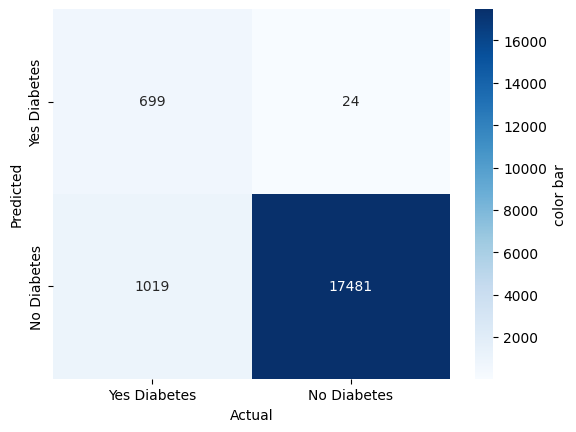

In [7]:
#generate heatmap for the confusion matrix using seaborn

sns.heatmap((confusion_matrix(y_test, y_pred_binary, labels=[1, 0]).T), cmap="Blues", annot=True, fmt='g', 
    cbar_kws={"orientation":"vertical", "label":"color bar"},xticklabels=["Yes Diabetes", "No Diabetes"],
    yticklabels=["Yes Diabetes", "No Diabetes"])
plt.xlabel("Actual")
plt.ylabel("Predicted")
#plt.savefig("02: Heatmap for Confusion Matrix")

plt.show()

In [8]:
#classification report giving metrics like sensitivity and specificity
print(classification_report(y_test, y_pred_binary, target_names=['No Diabetes','Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.94      1.00      0.97     17505
    Diabetes       0.97      0.41      0.57      1718

    accuracy                           0.95     19223
   macro avg       0.96      0.70      0.77     19223
weighted avg       0.95      0.95      0.94     19223



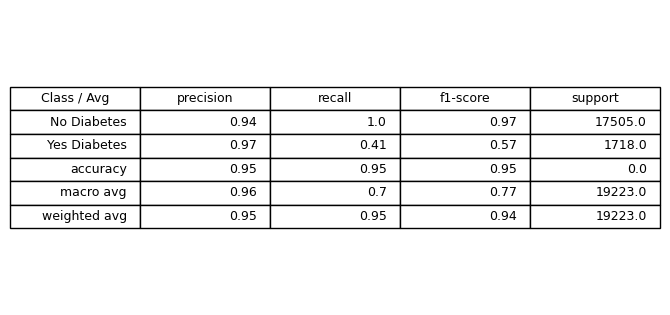

In [9]:
#classification report to include features for analysis and comparison 
#table for better presented
report = classification_report(
    y_test, y_pred_binary,
    target_names=['No Diabetes', 'Yes Diabetes'],
    output_dict=True
)
df = pd.DataFrame(report).T

row_order = ['No Diabetes', 'Yes Diabetes', 'accuracy', 'macro avg', 'weighted avg']
df = df.reindex([r for r in row_order if r in df.index])

num_cols = [c for c in df.columns if c != 'support']
df[num_cols] = df[num_cols].astype(float).round(2)
if 'support' in df.columns:
    df['support'] = df['support'].astype(int)

fig_h = 1.5 + 0.35 * len(df)         
fig_w = 6.8                           
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis('off')

table_data = np.column_stack([df.index.to_list(), df.values])
col_labels = ['Class / Avg'] + df.columns.to_list()

tbl = ax.table(cellText=table_data, colLabels=col_labels, loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.2)

plt.tight_layout()
#plt.savefig('02: classification_report.png', dpi=200, bbox_inches='tight')


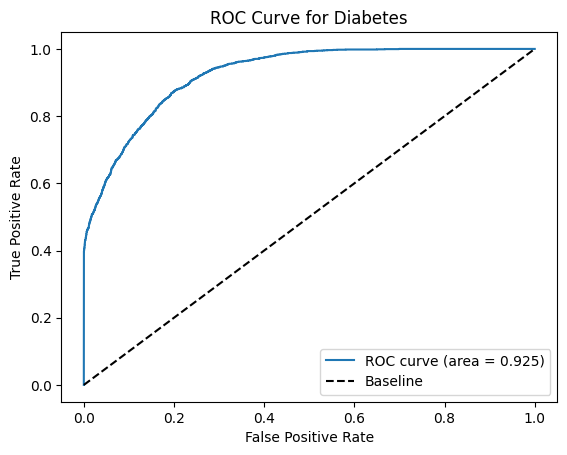

In [10]:
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label = "ROC curve (area = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], 'k--', label = 'Baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Diabetes")
plt.legend()
#plt.savefig("02: ROC Curve for predictions")

plt.show()

In [11]:
#Metrics summary for the overall analysis put into a frame from classification report

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

metrics_summary = {
    'Accuracy': accuracy_score(y_test, y_pred_binary),
    'Precision (No Diabetes)': precision_score(y_test, y_pred_binary, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred_binary, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred_binary, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred_binary, pos_label=1),
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'AUC': roc_auc}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)

                                0
Accuracy                 0.945742
Precision (No Diabetes)  0.944919
F1-Score (No Diabetes)   0.971032
Precision (Diabetes)     0.966805
F1-Score (Diabetes)      0.572716
Sensitivity              0.406868
Specificity              0.998629
AUC                      0.925303
